# 08 - Clustering CNEFE 2010 (BA)

Clustering independente dos setores de 2010 usando as features disponíveis:
- `situacao`: 1=urbano, 2=rural/localidade
- `tipo`: tipo do logradouro (RUA, FAZENDA, ESTRADA, AVENIDA, TRAVESSA...)

Depois cruzamos com os clusters de 2022 para construir a **matriz de transição**:
quais setores mudaram de perfil entre os dois momentos?

In [2]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import hdbscan
import umap
from pathlib import Path

con = duckdb.connect()
CNEFE_2010 = "'../data/cnefe_2010/*.snappy.parquet'"
OUTPUT_DIR = Path('../outputs')

In [3]:
# Perfil por setor: proporções de tipo + situacao
df_2010 = con.execute(f"""
    SELECT
        setor AS cod_setor,
        COUNT(*) AS total_enderecos,

        -- situacao
        SUM(CASE WHEN situacao = '1' THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_urbano,
        SUM(CASE WHEN situacao = '2' THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_rural,

        -- tipos urbanos
        SUM(CASE WHEN tipo = 'RUA'      THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_rua,
        SUM(CASE WHEN tipo = 'AVENIDA'  THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_avenida,
        SUM(CASE WHEN tipo = 'TRAVESSA' THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_travessa,
        SUM(CASE WHEN tipo = 'PRACA'    THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_praca,
        SUM(CASE WHEN tipo = 'ALAMEDA'  THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_alameda,
        SUM(CASE WHEN tipo = 'BECO'     THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_beco,

        -- tipos rurais
        SUM(CASE WHEN tipo = 'FAZENDA'  THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_fazenda,
        SUM(CASE WHEN tipo = 'ESTRADA'  THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_estrada,
        SUM(CASE WHEN tipo = 'CAMINHO'  THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_caminho,
        SUM(CASE WHEN tipo = 'RODOVIA'  THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_rodovia,
        SUM(CASE WHEN tipo = 'SITIO'    THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_sitio,
        SUM(CASE WHEN tipo = 'POVOADO'  THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_povoado

    FROM read_parquet({CNEFE_2010})
    WHERE uf = '29'
    GROUP BY setor
    HAVING COUNT(*) >= 5
""").df()

print(f'Setores: {len(df_2010):,}')
df_2010.head()

Setores: 23,763


,cod_setor,total_enderecos,prop_urbano,prop_rural,prop_rua,prop_avenida,prop_travessa,prop_praca,prop_alameda,prop_beco,prop_fazenda,prop_estrada,prop_caminho,prop_rodovia,prop_sitio,prop_povoado
0,290990125000008,51,0.0,1.0,0.000000,0.0,0.000000,0.0,0.0,0.00000,0.0,1.000000,0.0,0.000000,0.0,0.0
1,290990125000013,154,0.0,1.0,0.000000,0.0,0.000000,0.0,0.0,0.00000,0.0,1.000000,0.0,0.000000,0.0,0.0
2,290990125000015,96,0.0,1.0,0.895833,0.0,0.052083,0.0,0.0,0.00000,0.0,0.052083,0.0,0.000000,0.0,0.0
3,290990125000017,391,0.0,1.0,0.895141,0.0,0.079284,0.0,0.0,0.02046,0.0,0.000000,0.0,0.005115,0.0,0.0
4,290990125000023,84,0.0,1.0,0.000000,0.0,0.000000,0.0,0.0,0.00000,0.0,1.000000,0.0,0.000000,0.0,0.0


In [4]:
FEATURES = [
    'prop_urbano', 'prop_rural',
    'prop_rua', 'prop_avenida', 'prop_travessa', 'prop_praca', 'prop_alameda', 'prop_beco',
    'prop_fazenda', 'prop_estrada', 'prop_caminho', 'prop_rodovia', 'prop_sitio', 'prop_povoado'
]

df_2010 = df_2010.dropna(subset=FEATURES)

scaler = StandardScaler()
X = scaler.fit_transform(df_2010[FEATURES])
print(f'Shape: {X.shape}')

Shape: (23763, 14)


In [5]:
# HDBSCAN
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=200,
    min_samples=3,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)
df_2010['cluster'] = clusterer.fit_predict(X)

n_clusters = df_2010['cluster'].nunique() - (1 if -1 in df_2010['cluster'].values else 0)
n_noise    = (df_2010['cluster'] == -1).sum()
print(f'Clusters: {n_clusters}')
print(f'Ruído   : {n_noise:,} ({n_noise/len(df_2010)*100:.1f}%)')
print()
print(df_2010['cluster'].value_counts().sort_index())

Clusters: 12
Ruído   : 14,399 (60.6%)

cluster
-1     14399
 0       313
 1       976
 2      1600
 3       332
 4       677
 5       202
 6       204
 7      1742
 8      1257
 9       300
 10     1545
 11      216
Name: count, dtype: int64


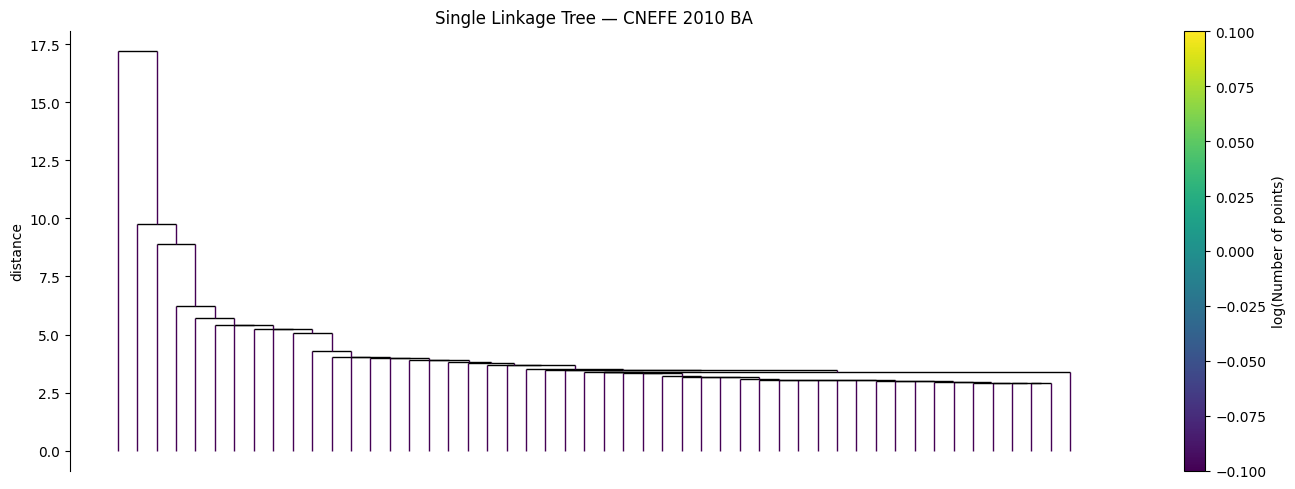

In [6]:
# Single Linkage Tree
fig, ax = plt.subplots(figsize=(14, 5))
clusterer.single_linkage_tree_.plot(
    truncate_mode='lastp', p=50,
    vary_line_width=False,
    cmap='viridis', colorbar=True, axis=ax
)
ax.set_title('Single Linkage Tree — CNEFE 2010 BA')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures/single_linkage_tree_2010_ba.png', dpi=150)
plt.show()

In [7]:
# Silhouette
mask = df_2010['cluster'] != -1
if mask.sum() > 1 and df_2010.loc[mask, 'cluster'].nunique() > 1:
    score = silhouette_score(X[mask], df_2010.loc[mask, 'cluster'], sample_size=10000, random_state=42)
    print(f'Silhouette Score 2010: {score:.4f}')

Silhouette Score 2010: 0.6724


In [8]:
# Nomenclatura dos clusters 2010
NOMES_2010 = {
    'prop_urbano':   'Urbano',
    'prop_rural':    'Rural',
    'prop_rua':      'Urbano Residencial',
    'prop_avenida':  'Urbano Comercial',
    'prop_travessa': 'Urbano Denso',
    'prop_praca':    'Urbano Central',
    'prop_alameda':  'Urbano Residencial',
    'prop_beco':     'Urbano Denso',
    'prop_fazenda':  'Rural Agrícola',
    'prop_estrada':  'Rural / Peri-urbano',
    'prop_caminho':  'Rural',
    'prop_rodovia':  'Peri-urbano',
    'prop_sitio':    'Rural Agrícola',
    'prop_povoado':  'Localidade Rural',
}

perfil_z = (df_2010[df_2010['cluster'] != -1]
            .groupby('cluster')[FEATURES]
            .mean())

def nomear(row):
    feat = row.idxmax()
    return NOMES_2010[feat]

cluster_nomes = perfil_z.apply(nomear, axis=1)

contagem = {}
for nome in cluster_nomes:
    contagem[nome] = contagem.get(nome, 0) + 1

contagem_uso = {}
nomes_2010 = {}
for cid, nome in cluster_nomes.items():
    contagem_uso[nome] = contagem_uso.get(nome, 0) + 1
    nomes_2010[cid] = f'{nome} {contagem_uso[nome]}' if contagem[nome] > 1 else nome

df_2010['cluster_nome'] = df_2010['cluster'].map(
    lambda x: nomes_2010.get(x, 'Ruído') if x != -1 else 'Ruído'
)

tamanhos = df_2010[df_2010['cluster'] != -1]['cluster'].value_counts().sort_index()
print('Clusters 2010:')
for cid, nome in sorted(nomes_2010.items()):
    print(f'  C{cid:>2} → {nome:<30} (n={tamanhos[cid]:,})')

Clusters 2010:
  C 0 → Urbano 1                       (n=313)
  C 1 → Rural 1                        (n=976)
  C 2 → Rural 2                        (n=1,600)
  C 3 → Rural 3                        (n=332)
  C 4 → Rural 4                        (n=677)
  C 5 → Rural 5                        (n=202)
  C 6 → Rural 6                        (n=204)
  C 7 → Rural 7                        (n=1,742)
  C 8 → Urbano 2                       (n=1,257)
  C 9 → Urbano 3                       (n=300)
  C10 → Urbano 4                       (n=1,545)
  C11 → Urbano 5                       (n=216)


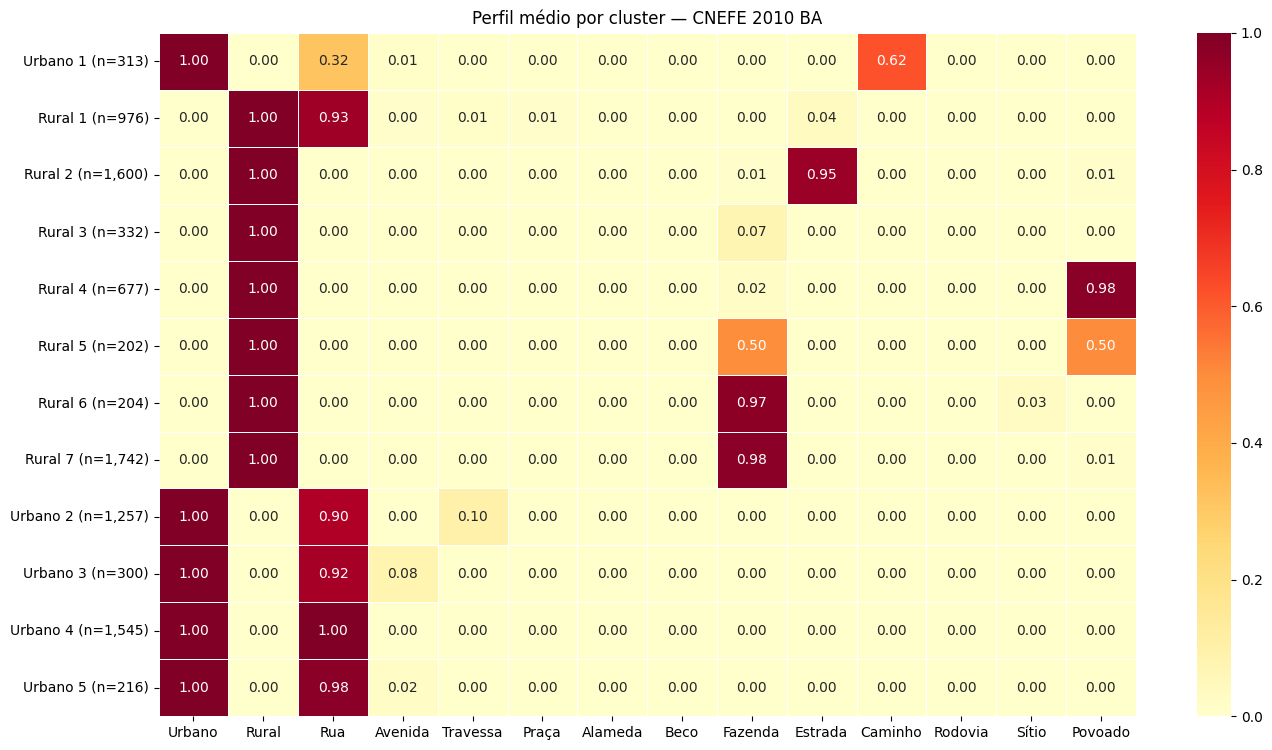

In [9]:
# Heatmap perfil 2010
FEAT_LABEL = {
    'prop_urbano': 'Urbano', 'prop_rural': 'Rural',
    'prop_rua': 'Rua', 'prop_avenida': 'Avenida',
    'prop_travessa': 'Travessa', 'prop_praca': 'Praça',
    'prop_alameda': 'Alameda', 'prop_beco': 'Beco',
    'prop_fazenda': 'Fazenda', 'prop_estrada': 'Estrada',
    'prop_caminho': 'Caminho', 'prop_rodovia': 'Rodovia',
    'prop_sitio': 'Sítio', 'prop_povoado': 'Povoado',
}

perfil = (df_2010[df_2010['cluster'] != -1]
          .groupby('cluster')[FEATURES].mean()
          .rename(columns=FEAT_LABEL))
perfil.index = [f"{nomes_2010[i]} (n={tamanhos[i]:,})" for i in perfil.index]

fig, ax = plt.subplots(figsize=(14, max(5, len(perfil) * 0.55 + 1)))
sns.heatmap(perfil, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Perfil médio por cluster — CNEFE 2010 BA')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures/perfil_clusters_2010_ba.png', dpi=150)
plt.show()

Setores com match em ambos os anos: 7,650
  cluster_2010          cluster_2022
0      Rural 2  Rural / Agropecuário
1      Rural 2                 Ruído
2      Rural 1                 Ruído
3      Rural 2                 Ruído
4      Rural 2                 Ruído


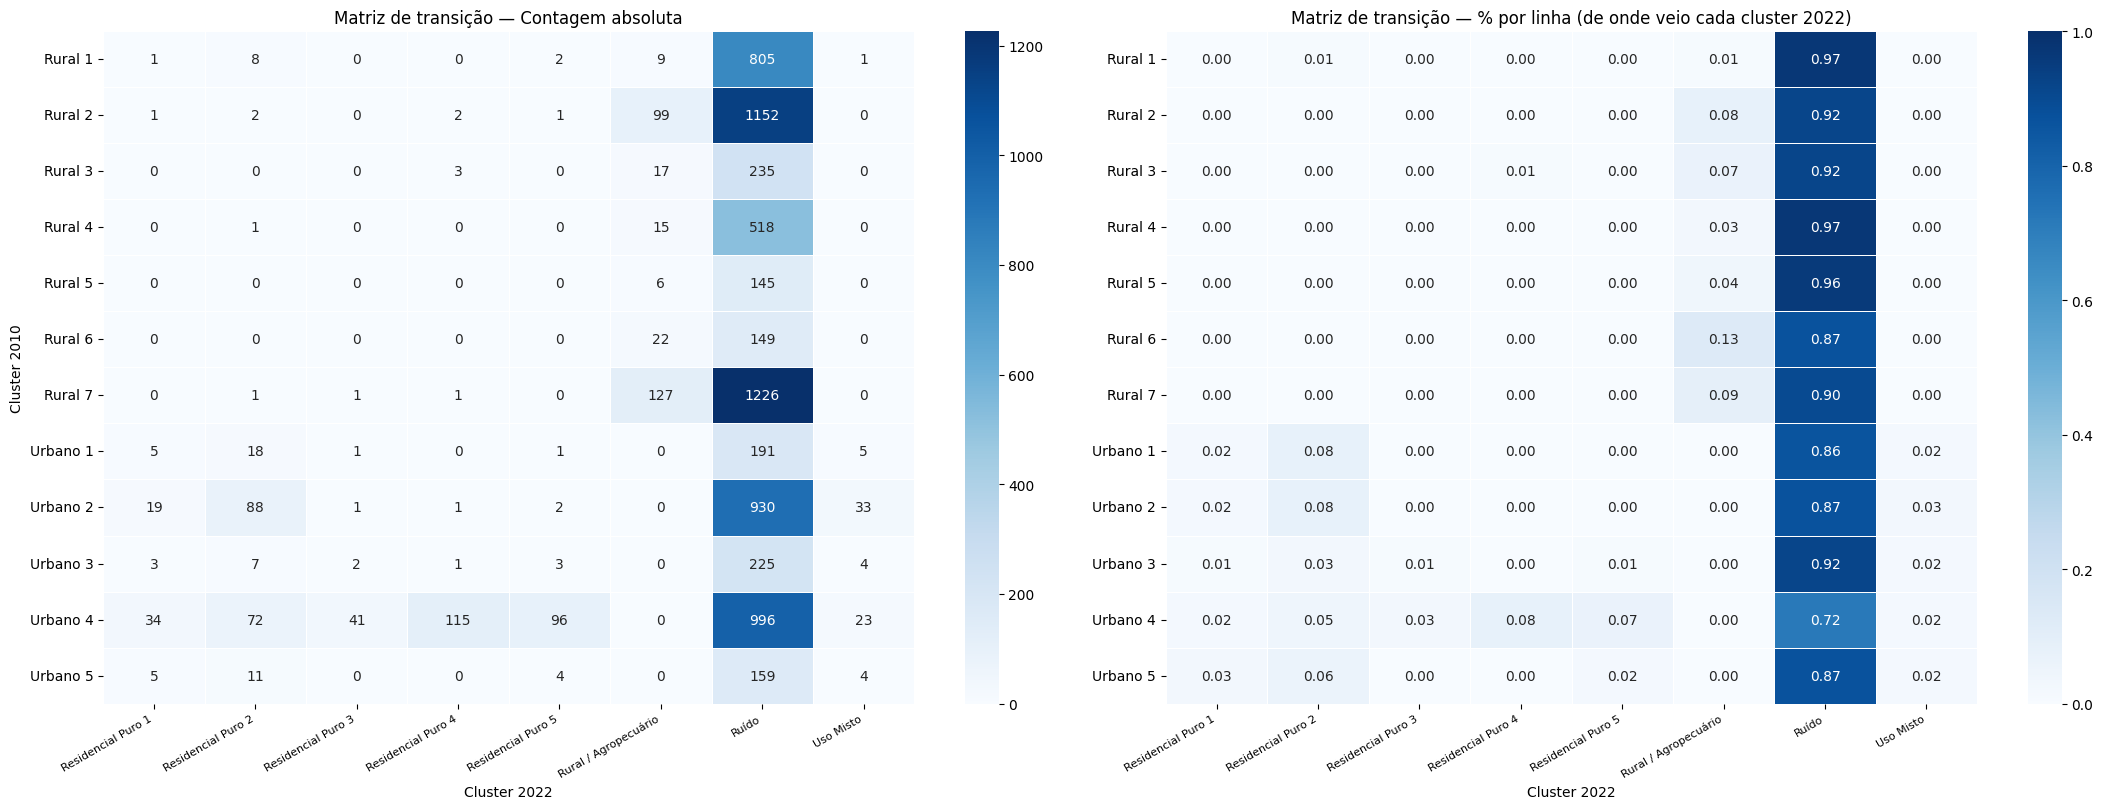

In [10]:
# Matriz de transição: cluster 2010 → cluster 2022
# Carrega direto dos parquets para não depender do estado da sessão
df_2010_saved = pd.read_parquet(OUTPUT_DIR / 'setores_clusterizados_2010_ba.parquet')
df_2022_saved = pd.read_parquet(OUTPUT_DIR / 'setores_clusterizados.parquet')

# Códigos de 2022 têm sufixo 'P' — removido antes do join
df_2022_saved['cod_setor'] = df_2022_saved['COD_SETOR'].str[:-1]

df_trans = (df_2010_saved[df_2010_saved['cluster'] != -1]
            .merge(
                df_2022_saved[['cod_setor', 'cluster_nome']].rename(columns={'cluster_nome': 'cluster_2022'}),
                on='cod_setor', how='inner'
            )
            .rename(columns={'cluster_nome': 'cluster_2010'}))

print(f'Setores com match em ambos os anos: {len(df_trans):,}')
print(df_trans[['cluster_2010', 'cluster_2022']].head())

matriz_abs = pd.crosstab(df_trans['cluster_2010'], df_trans['cluster_2022'])
matriz_pct = matriz_abs.div(matriz_abs.sum(axis=1), axis=0).round(2)

fig, axes = plt.subplots(1, 2, figsize=(22, max(5, len(matriz_pct) * 0.6 + 1)))

sns.heatmap(matriz_abs, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Matriz de transição — Contagem absoluta')
axes[0].set_xlabel('Cluster 2022')
axes[0].set_ylabel('Cluster 2010')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right', fontsize=8)

sns.heatmap(matriz_pct, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, ax=axes[1], vmin=0, vmax=1)
axes[1].set_title('Matriz de transição — % por linha (de onde veio cada cluster 2022)')
axes[1].set_xlabel('Cluster 2022')
axes[1].set_ylabel('')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures/matriz_transicao_2010_2022_ba.png', dpi=150)
plt.show()

/home/wesleiferreira/Documentos/GitHub/trabalho-topicos-4/.venv/lib64/python3.14/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
/home/wesleiferreira/Documentos/GitHub/trabalho-topicos-4/.venv/lib64/python3.14/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


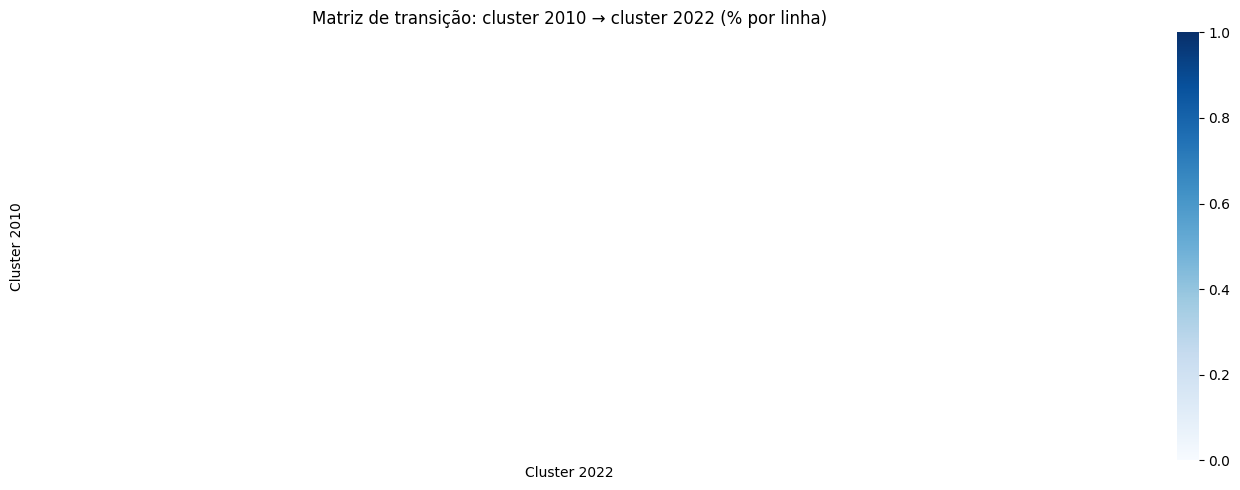

In [11]:
# Matriz de transição: cluster 2010 → cluster 2022
df_2022 = pd.read_parquet(OUTPUT_DIR / 'setores_clusterizados.parquet')
df_2022 = df_2022.rename(columns={'COD_SETOR': 'cod_setor'})

df_trans = df_2010[df_2010['cluster'] != -1].merge(
    df_2022[['cod_setor', 'cluster_nome']].rename(columns={'cluster_nome': 'cluster_2022'}),
    on='cod_setor', how='inner'
)
df_trans = df_trans.rename(columns={'cluster_nome': 'cluster_2010'})

matriz = pd.crosstab(df_trans['cluster_2010'], df_trans['cluster_2022'])

# normaliza por linha (% de cada cluster 2010 que foi para cada cluster 2022)
matriz_pct = matriz.div(matriz.sum(axis=1), axis=0).round(2)

fig, ax = plt.subplots(figsize=(14, max(5, len(matriz_pct) * 0.6 + 1)))
sns.heatmap(matriz_pct, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_title('Matriz de transição: cluster 2010 → cluster 2022 (% por linha)')
ax.set_xlabel('Cluster 2022')
ax.set_ylabel('Cluster 2010')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures/matriz_transicao_2010_2022_ba.png', dpi=150)
plt.show()

In [12]:
# Salvar
df_2010.to_parquet(OUTPUT_DIR / 'setores_clusterizados_2010_ba.parquet', index=False)
print('Salvo: outputs/setores_clusterizados_2010_ba.parquet')

Salvo: outputs/setores_clusterizados_2010_ba.parquet
